In [1]:
import earthaccess


/opt/anaconda3/envs/earthaccess-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pathlib


In [3]:
auth = earthaccess.login(persist=True)


In [4]:
results = earthaccess.search_datasets(instrument="oci")
print(f"Datasets found: {len(results)}")
for ds in results:
    print(ds["short_name"])

Datasets found: 68


KeyError: 'short_name'

In [ ]:
for item in results:
    summary = item.summary()
    print(summary["short-name"])

In [8]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    count=1,
)
print(f"Granules found: {len(results)}")


Granules found: 1


In [12]:
tspan = ("2024-05-01", "2025-05-16")
bbox = (-76.75, 36.97, -75.74, 39.01)
clouds = (0, 50)

In [13]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
print(f"Granules found: {len(results)}")


Granules found: 24


In [14]:
results[0]


Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L2_BGC_NRT'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 40.47089, 'Longitude': -67.16946}, {'Latitude': 34.8355, 'Longitude': -97.05894}, {'Latitude': 17.43481, 'Longitude': -90.32227}, {'Latitude': 22.62021, 'Longitude': -65.21797}, {'Latitude': 40.47089, 'Longitude': -67.16946}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-01-14T18:03:53Z', 'BeginningDateTime': '2025-01-14T17:58:54Z'}}
Size(MB): 16.258601188659668
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250114T175854.L2.OC_BGC.V3_0.NRT.nc']

In [15]:
results[1]


Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L2_BGC_NRT'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 43.6112, 'Longitude': -65.72241}, {'Latitude': 37.83741, 'Longitude': -96.98454}, {'Latitude': 20.5393, 'Longitude': -89.67879}, {'Latitude': 25.78035, 'Longitude': -63.98996}, {'Latitude': 43.6112, 'Longitude': -65.72241}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-01-28T17:53:17Z', 'EndingDateTime': '2025-01-28T17:58:16Z'}}
Size(MB): 16.84917163848877
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250128T175317.L2.OC_BGC.V3_0.NRT.nc']

In [16]:
results[2]


Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L2_BGC_NRT'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 44.15192, 'Longitude': -58.48368}, {'Latitude': 38.35047, 'Longitude': -90.00829}, {'Latitude': 21.06225, 'Longitude': -82.58262}, {'Latitude': 26.31337, 'Longitude': -56.78983}, {'Latitude': 44.15192, 'Longitude': -58.48368}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-01-30T17:24:22Z', 'EndingDateTime': '2025-01-30T17:29:22Z'}}
Size(MB): 23.740558624267578
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250130T172422.L2.OC_BGC.V3_0.NRT.nc']

In [17]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    temporal=tspan,
    bounding_box=bbox,
    count=2,
)
print(f"Granules found: {len(results)}")


Granules found: 2


In [18]:
paths = earthaccess.open(results)


QUEUEING TASKS | : 100%|█████████████████████████| 2/2 [00:00<00:00, 608.49it/s]
PROCESSING TASKS | : 100%|████████████████████████| 2/2 [00:01<00:00,  1.25it/s]
COLLECTING RESULTS | : 100%|███████████████████| 2/2 [00:00<00:00, 19831.22it/s]


In [19]:
with paths[0] as file:
    line = file.readline().strip()
line

b'\x89HDF'

In [20]:
directory = pathlib.Path("L1B")
directory.mkdir(exist_ok=True)
paths = earthaccess.download(results, directory)

QUEUEING TASKS | : 100%|████████████████████████| 2/2 [00:00<00:00, 2178.86it/s]
PROCESSING TASKS | : 100%|█████████████████████| 2/2 [00:00<00:00, 14193.92it/s]
COLLECTING RESULTS | : 100%|███████████████████| 2/2 [00:00<00:00, 11554.56it/s]


In [21]:
paths


['L1B/PACE_OCI.20240501T165311.L1B.V3.nc',
 'L1B/PACE_OCI.20240501T165811.L1B.V3.nc']

In [22]:
import cartopy.crs as ccrs
import earthaccess
import h5netcdf
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [23]:
auth = earthaccess.login(persist=True)


In [24]:
tspan = ("2024-04-01", "2024-04-16")
bbox = (-76.75, 36.97, -75.74, 39.01)

results = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    temporal=tspan,
    bounding_box=bbox,
)
print(f"Granules found: {len(results)}")


Granules found: 19


In [25]:
paths = earthaccess.open(results)


QUEUEING TASKS | : 100%|██████████████████████| 19/19 [00:00<00:00, 2309.24it/s]
PROCESSING TASKS | : 100%|██████████████████████| 19/19 [00:05<00:00,  3.67it/s]
COLLECTING RESULTS | : 100%|████████████████| 19/19 [00:00<00:00, 130215.32it/s]


In [26]:
try:
    paths[0].f.bucket
except AttributeError:
    raise "The result opened without an S3FileSystem."

TypeError: exceptions must derive from BaseException

In [27]:
dataset = xr.open_dataset(paths[0])
dataset

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/34)
    title:                             PACE OCI Level-1B Data
    instrument:                        OCI
    platform:                          PACE
    processing_level:                  L1B
    cdm_data_type:                     swath
    geospatial_lat_units:              degrees_north
    ...                                ...
    time_coverage_start:               2024-04-01T17:29:47.078Z
    time_coverage_end:                 2024-04-01T17:34:46.961Z
    history:                           2025-02-05T19:43:33Z: l1bgen_oci ephfi...
    processing_version:                3
    identifier_product_doi_authority:  https://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L1B/SCI/3

In [28]:
with h5netcdf.File(paths[0]) as file:
    groups = list(file)
groups

['sensor_band_parameters',
 'scan_line_attributes',
 'geolocation_data',
 'navigation_data',
 'observation_data']

In [29]:
dataset = xr.open_dataset(paths[0], group="observation_data")
dataset

<xarray.Dataset> Size: 5GB
Dimensions:    (blue_bands: 119, scans: 1710, pixels: 1272, red_bands: 163,
                SWIR_bands: 9)
Dimensions without coordinates: blue_bands, scans, pixels, red_bands, SWIR_bands
Data variables:
    rhot_blue  (blue_bands, scans, pixels) float32 1GB ...
    rhot_red   (red_bands, scans, pixels) float32 1GB ...
    rhot_SWIR  (SWIR_bands, scans, pixels) float32 78MB ...
    qual_blue  (blue_bands, scans, pixels) float32 1GB ...
    qual_red   (red_bands, scans, pixels) float32 1GB ...
    qual_SWIR  (SWIR_bands, scans, pixels) float32 78MB ...

In [30]:
dataset["rhot_blue"].sizes


Frozen({'blue_bands': 119, 'scans': 1710, 'pixels': 1272})

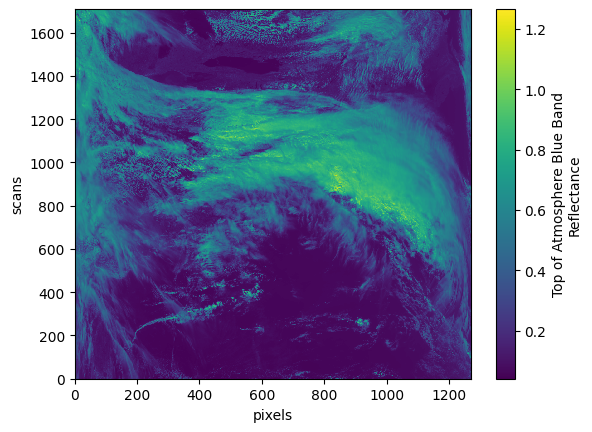

In [31]:
plot = dataset["rhot_blue"].sel({"blue_bands": 100}).plot()


In [33]:
tspan = ("2024-04-01", "2025-04-23")
bbox = (-76.75, 36.97, -75.74, 39.01)
clouds = (0, 50)

results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
print(f"Granules found: {len(results)}")


Granules found: 17


In [34]:
paths = earthaccess.open(results)
try:
    paths[0].f.bucket
except AttributeError:
    raise "The result opened without an S3FileSystem."

QUEUEING TASKS | : 100%|██████████████████████| 17/17 [00:00<00:00, 3943.32it/s]
PROCESSING TASKS | : 100%|██████████████████████| 17/17 [00:05<00:00,  3.05it/s]
COLLECTING RESULTS | : 100%|█████████████████| 17/17 [00:00<00:00, 35723.03it/s]


TypeError: exceptions must derive from BaseException

In [35]:
with h5netcdf.File(paths[0]) as file:
    groups = list(file)
groups

['sensor_band_parameters',
 'scan_line_attributes',
 'geophysical_data',
 'navigation_data',
 'processing_control']

In [36]:
dataset = xr.open_dataset(paths[0], group="geophysical_data")
rrs = dataset["Rrs"]
rrs

<xarray.DataArray 'Rrs' (number_of_lines: 1709, pixels_per_line: 1272,
                         wavelength_3d: 172)> Size: 1GB
[373901856 values with dtype=float32]
Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

In [37]:
rrs.sizes


Frozen({'number_of_lines': 1709, 'pixels_per_line': 1272, 'wavelength_3d': 172})

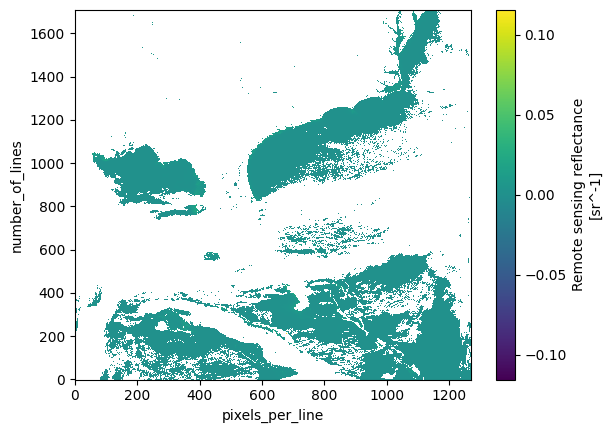

In [38]:
plot = rrs.sel({"wavelength_3d": 100}).plot(cmap="viridis")


In [39]:
dataset = xr.open_dataset(paths[0], group="navigation_data")
dataset = dataset.set_coords(("longitude", "latitude"))
dataset = dataset.rename({"pixel_control_points": "pixels_per_line"})
dataset = xr.merge((rrs, dataset.coords))
dataset

ValueError: cannot rename 'pixel_control_points' because it is not a variable or dimension in this dataset

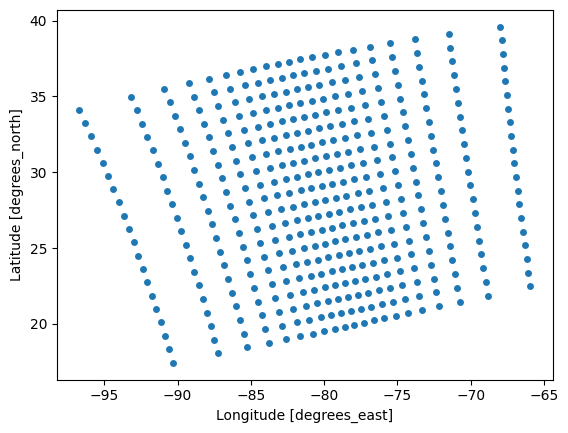

In [40]:
plot = dataset.sel(
    {
        "number_of_lines": slice(None, None, 1720 // 20),
        "pixels_per_line": slice(None, None, 1272 // 20),
    },
).plot.scatter(x="longitude", y="latitude")

In [41]:
rrs = dataset["Rrs"].sel({"wavelength_3d": 100})
plot = rrs.plot(x="longitude", y="latitude", cmap="viridis", vmin=0)

KeyError: "No variable named 'Rrs'. Variables on the dataset include ['longitude', 'latitude', 'tilt']"

TypeError: Axes.hist() got multiple values for argument 'x'

/opt/anaconda3/envs/earthaccess-env/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


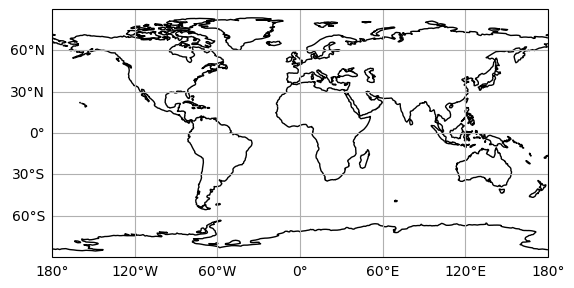

In [42]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
plot = rrs.plot(x="longitude", y="latitude", cmap="viridis", vmin=0, ax=ax)